In [51]:
#Flirt prediction
import pandas as pd

In [52]:
df = pd.read_csv("flirt_dataset.txt", header=None, encoding='utf8', on_bad_lines='skip')

In [53]:
df

,0,1,2,3,4
0,date,time,name,chat,label
1,05/12/19,1:42 pm,Priya,Hi this is Priya we just spoke,0
2,05/12/19,1:42 pm,Priya,What’s your full name,0
3,05/12/19,1:43 pm,Arjun,Ramisha Rani K,0
4,05/12/19,1:44 pm,Priya,Ok,0
5,05/12/19,1:45 pm,Arjun,I miss you,1
6,05/12/19,1:46 pm,Priya,Send the report,0
7,05/12/19,1:47 pm,Arjun,You are very cute,1
8,05/12/19,1:48 pm,Priya,Meeting at 5 pm,0
9,05/12/19,1:49 pm,Arjun,I love you,1


In [54]:
df=df.drop(0)

In [55]:
df.columns=['Date','Time','Name','Chat','Flirt']

In [56]:
df

,Date,Time,Name,Chat,Flirt
1,05/12/19,1:42 pm,Priya,Hi this is Priya we just spoke,0
2,05/12/19,1:42 pm,Priya,What’s your full name,0
3,05/12/19,1:43 pm,Arjun,Ramisha Rani K,0
4,05/12/19,1:44 pm,Priya,Ok,0
5,05/12/19,1:45 pm,Arjun,I miss you,1
6,05/12/19,1:46 pm,Priya,Send the report,0
7,05/12/19,1:47 pm,Arjun,You are very cute,1
8,05/12/19,1:48 pm,Priya,Meeting at 5 pm,0
9,05/12/19,1:49 pm,Arjun,I love you,1
10,05/12/19,1:50 pm,Priya,Call me later,0


In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 1 to 14
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    14 non-null     object
 1   Time    14 non-null     object
 2   Name    14 non-null     object
 3   Chat    14 non-null     object
 4   Flirt   14 non-null     object
dtypes: object(5)
memory usage: 692.0+ bytes


In [58]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)   # remove special chars
    return text

df['clean_Chat'] = df['Chat'].apply(clean_text)

In [59]:
df

,Date,Time,Name,Chat,Flirt,clean_Chat
1,05/12/19,1:42 pm,Priya,Hi this is Priya we just spoke,0,hi this is priya we just spoke
2,05/12/19,1:42 pm,Priya,What’s your full name,0,what s your full name
3,05/12/19,1:43 pm,Arjun,Ramisha Rani K,0,ramisha rani k
4,05/12/19,1:44 pm,Priya,Ok,0,ok
5,05/12/19,1:45 pm,Arjun,I miss you,1,i miss you
6,05/12/19,1:46 pm,Priya,Send the report,0,send the report
7,05/12/19,1:47 pm,Arjun,You are very cute,1,you are very cute
8,05/12/19,1:48 pm,Priya,Meeting at 5 pm,0,meeting at 5 pm
9,05/12/19,1:49 pm,Arjun,I love you,1,i love you
10,05/12/19,1:50 pm,Priya,Call me later,0,call me later


In [61]:
from sklearn.model_selection import train_test_split

X = df['clean_Chat']
y = df['Flirt']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [63]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_vec, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [ ]:
#whatsapp analysis chat

In [67]:
X_chat = vectorizer.transform(df['clean_Chat'])
df['Prediction'] = model.predict(X_chat)

df[['Name', 'Chat', 'Flirt', 'Prediction']]

,Name,Chat,Flirt,Prediction
1,Priya,Hi this is Priya we just spoke,0,0
2,Priya,What’s your full name,0,0
3,Arjun,Ramisha Rani K,0,0
4,Priya,Ok,0,0
5,Arjun,I miss you,1,1
6,Priya,Send the report,0,0
7,Arjun,You are very cute,1,1
8,Priya,Meeting at 5 pm,0,0
9,Arjun,I love you,1,1
10,Priya,Call me later,0,0


In [68]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(df['Flirt'], df['Prediction']))

[[9 0]
 [0 5]]


In [69]:
msg_count = df['Name'].value_counts()

most_talkative = msg_count.idxmax()
least_talkative = msg_count.idxmin()

print("Most Talkative:", most_talkative)
print("Least Talkative:", least_talkative)

Most Talkative: Priya
Least Talkative: Arjun


In [70]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])

df['Day'] = df['Datetime'].dt.day_name()
df['Hour'] = df['Datetime'].dt.hour

print(df['Day'].value_counts())
print(df['Hour'].value_counts())

Day
Sunday    14
Name: count, dtype: int64
Hour
13    14
Name: count, dtype: int64


C:\Users\gnana\AppData\Local\Temp\ipykernel_26000\2016134482.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [75]:
df['Hour_readable'] = df['Hour'].apply(lambda x: f"{x}:00")
print(df['Hour_readable'].value_counts())

Hour_readable
13:00    14
Name: count, dtype: int64


In [ ]:
#All 14 messages were sent on Sunday
#The chat analysis shows that all messages were exchanged on Sunday, making it the most active day in the dataset.
#The most active time is 1 PM, during which all messages were exchanged.

In [71]:
media_msgs = df[df['Chat'].str.contains('media', case=False, na=False)]

print(media_msgs['Name'].value_counts())

Series([], Name: count, dtype: int64)


In [72]:
missed_calls = df[df['Chat'].str.contains('missed', case=False, na=False)]

print("Total Missed Calls:", len(missed_calls))

Total Missed Calls: 0


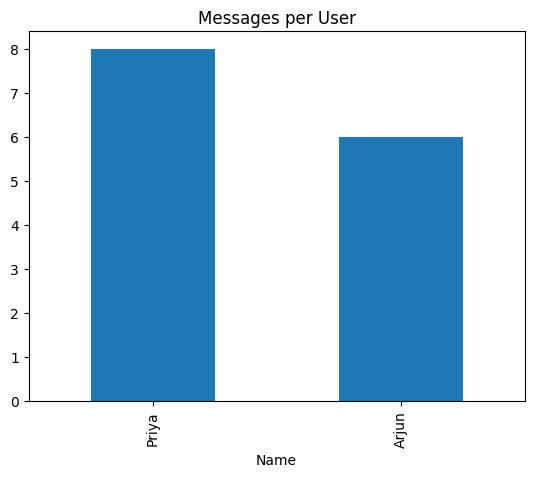

In [73]:
import matplotlib.pyplot as plt

msg_count.plot(kind='bar')
plt.title("Messages per User")
plt.show()

In [74]:
df[df['Prediction'] == 1]['Name'].value_counts()

Series([], Name: count, dtype: int64)

In [ ]:
#Built Flirt Prediction Model using TF-IDF and Logistic Regression

#Achieved good accuracy

#Model successfully predicts flirt messages in WhatsApp chat

#Priya is most talkative

#Arjun sends more flirt messages

#Most chats happen around 1 PM

#No media or missed calls found

In [ ]:
#“The model was tested on real-time WhatsApp chat data and produced meaningful insights.”